In [6]:
import sys
import subprocess

REQUIRED_PACKAGES = ["timm", "captum", "wandb", "pyyaml"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES])
print("Minimal notebook dependencies installed")

Minimal notebook dependencies installed


In [1]:
import os
import random
import json
import hashlib
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import timm
import captum
import sklearn

from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"timm: {timm.__version__}")
print(f"captum: {captum.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.12.3
NumPy: 1.26.4
Pandas: 3.0.1
Matplotlib: 3.10.8
PyTorch: 2.10.0+cu128
torchvision: 0.25.0+cu128
timm: 1.0.25
captum: 0.8.0
scikit-learn: 1.8.0


In [3]:
GLOBAL_SEED = 42

def set_seed(seed: int = GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"All seeds set to {seed}")

set_seed(GLOBAL_SEED)

All seeds set to 42


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    mem = getattr(props, "total_memory", None) or getattr(props, "total_mem", None)
    print(f"GPU Memory: {mem / 1e9:.2f} GB")

[✓] Device: cpu


In [7]:
import pathlib

PROJECT_ROOT = pathlib.Path("/home/yash/yc432")

DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "archive (1)" / "EuroSAT",
    PROJECT_ROOT / "data" / "archive" / "EuroSAT",
    PROJECT_ROOT / "data" / "EuroSAT",
    PROJECT_ROOT / "EuroSAT",
]

DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), None)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_ROOT}")

if DATA_DIR is None:
    checked = "\\n".join(str(p) for p in DATA_CANDIDATES)
    raise FileNotFoundError(f"Dataset folder not found. Checked:\\n{checked}")

for d in [
    "configs",
    "data/splits",
    "data/eda",
    "src",
    "src/data",
    "src/models",
    "src/xai",
    "src/evaluation",
    "src/utils",
    "checkpoints",
    "results/metrics",
    "results/figures",
    "results/heatmaps",
    "results/failure_cases",
    "notebooks",
    "tests",
    "logs",
]:
    (PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

for d in ["src", "src/data", "src/models", "src/xai", "src/evaluation", "src/utils"]:
    (PROJECT_ROOT / d / "__init__.py").touch(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_DIR}")

class_folders = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir() and not p.name.startswith(".")])
print(f"Found {len(class_folders)} class folders")
print("Classes:", class_folders)
print("Project directories ready")

Project root: /home/yash/yc432
Dataset path: /home/yash/yc432/EuroSAT
Found 10 class folders
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Project directories ready


In [8]:
import yaml

config = {
    "project": {
        "name": "coloring-black-boxes",
        "author": "Yash Chourasia",
        "student_id": "249015981",
        "email": "yc432@student.le.ac.uk",
        "seed": GLOBAL_SEED,
    },
    "data": {
        "dataset": "EuroSAT",
        "data_dir": str(DATA_DIR),
        "splits_dir": str(PROJECT_ROOT / "data" / "splits"),
        "num_classes": 10,
        "image_size": 64,
        "channels": 3,
        "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
        "split_seed": GLOBAL_SEED,
    },
    "augmentation": {
        "train": {
            "random_horizontal_flip": 0.5,
            "random_vertical_flip": 0.5,
            "random_rotation_degrees": 15,
            "color_jitter": {
                "brightness": 0.2,
                "contrast": 0.2,
                "saturation": 0.1,
                "hue": 0.05,
            },
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
        },
        "eval": {
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
        },
    },
    "training": {
        "resnet18": {
            "pretrained": True,
            "pretrained_source": "torchvision_imagenet1k",
            "optimizer": "AdamW",
            "lr": 1e-4,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 2,
        },
        "vit_tiny": {
            "pretrained": True,
            "pretrained_source": "timm_imagenet21k",
            "model_name": "vit_tiny_patch16_224",
            "patch_size": 16,
            "optimizer": "AdamW",
            "lr": 1e-4,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 2,
        },
        "vim": {
            "pretrained": False,
            "optimizer": "AdamW",
            "lr": 1e-4,
            "lr_fallback": 1e-5,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "warmup_epochs": 5,
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 2,
            "fp16": True,
        },
    },
    "xai": {
        "integrated_gradients": {"n_steps": 50, "baseline": "zero"},
        "smoothgrad": {"n_samples": 50, "noise_sigma_fraction": 0.1},
        "gradcam": {"target_layer": "layer4", "upsample_size": [64, 64]},
        "attention_rollout": {"discard_ratio": 0.0},
    },
    "evaluation": {
        "n_test_images": 200,
        "insertion_deletion_steps": 20,
        "stability_noise_levels": [0.01, 0.05, 0.1],
        "sensitivity_top_k_fraction": 0.20,
        "min_failure_patterns": 3,
    },
}

config_path = PROJECT_ROOT / "configs" / "master_config.yaml"
with open(config_path, "w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Master config saved to: {config_path}")

Master config saved to: /home/yash/yc432/configs/master_config.yaml


In [10]:
import pandas as pd

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])

CLASS_NAMES = [d.name for d in class_dirs]
NUM_CLASSES = len(CLASS_NAMES)

assert NUM_CLASSES == 10, f"Expected 10 classes, found {NUM_CLASSES}"

file_records = []

for class_dir in class_dirs:
    class_name = class_dir.name

    image_files = [
        f for f in class_dir.rglob("*")
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]

    print(f"{class_name}: {len(image_files)} images found")

    for img_path in image_files:
        file_records.append({
            "filepath": str(img_path),
            "filename": img_path.name,
            "class_name": class_name,
            "class_idx": CLASS_NAMES.index(class_name),
        })

df_all = pd.DataFrame(file_records)
total_images = len(df_all)

assert total_images > 0, "No images found in DATA_DIR"

print(f"Total images: {total_images}")
print(f"Classes: {NUM_CLASSES}")
print("\nClass distribution:")
print(df_all["class_name"].value_counts().sort_index())

AnnualCrop: 3000 images found
Forest: 3000 images found
HerbaceousVegetation: 3000 images found
Highway: 2500 images found
Industrial: 2500 images found
Pasture: 2000 images found
PermanentCrop: 2500 images found
Residential: 3000 images found
River: 2500 images found
SeaLake: 3000 images found
Total images: 27000
Classes: 10

Class distribution:
class_name
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64


In [11]:
print("Verifying image properties (sampling 100 images)...")

sample_paths = df_all["filepath"].sample(n=100, random_state=GLOBAL_SEED).tolist()

sizes = []
modes = []
corrupt_files = []

for pth in sample_paths:
    try:
        img = Image.open(pth)
        img.verify()
        img = Image.open(pth)
        sizes.append(img.size)
        modes.append(img.mode)
    except Exception as e:
        corrupt_files.append((pth, str(e)))

unique_sizes = set(sizes)
unique_modes = set(modes)

print(f"  Unique sizes: {unique_sizes}")
print(f"  Unique modes: {unique_modes}")
print(f"  Corrupt files: {len(corrupt_files)}")

if corrupt_files:
    print("  Corrupt files:")
    for path, err in corrupt_files[:10]:
        print(f"    {path}: {err}")
else:
    print("All sampled images are valid")

assert unique_sizes == {(64, 64)}, f"Unexpected image sizes found: {unique_sizes}"
assert unique_modes == {"RGB"}, f"Unexpected image modes found: {unique_modes}"
print("Image verification passed")

Verifying image properties (sampling 100 images)...
  Unique sizes: {(64, 64)}
  Unique modes: {'RGB'}
  Corrupt files: 0
All sampled images are valid
Image verification passed


In [12]:
split_ratios = config["data"]["split_ratios"]
split_seed = config["data"]["split_seed"]

df_train, df_temp = train_test_split(
    df_all,
    test_size=(split_ratios["val"] + split_ratios["test"]),
    random_state=split_seed,
    stratify=df_all["class_idx"],
)

val_fraction = split_ratios["val"] / (split_ratios["val"] + split_ratios["test"])
df_val, df_test = train_test_split(
    df_temp,
    test_size=(1 - val_fraction),
    random_state=split_seed,
    stratify=df_temp["class_idx"],
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Split sizes:")
print(f"  Train: {len(df_train)} ({100 * len(df_train) / total_images:.1f}%)")
print(f"  Val:   {len(df_val)} ({100 * len(df_val) / total_images:.1f}%)")
print(f"  Test:  {len(df_test)} ({100 * len(df_test) / total_images:.1f}%)")
print(f"  Total: {len(df_train) + len(df_val) + len(df_test)}")

train_files = set(df_train["filepath"])
val_files = set(df_val["filepath"])
test_files = set(df_test["filepath"])

assert len(train_files & val_files) == 0, "LEAKAGE: train ∩ val"
assert len(train_files & test_files) == 0, "LEAKAGE: train ∩ test"
assert len(val_files & test_files) == 0, "LEAKAGE: val ∩ test"
assert len(train_files | val_files | test_files) == total_images, "Missing images!"

print("No data leakage detected")
print("All images accounted for")

Split sizes:
  Train: 18900 (70.0%)
  Val:   4050 (15.0%)
  Test:  4050 (15.0%)
  Total: 27000
No data leakage detected
All images accounted for


In [14]:
splits_dir = PROJECT_ROOT / "data" / "splits"

df_train.to_csv(splits_dir / "train.csv", index=False)
df_val.to_csv(splits_dir / "val.csv", index=False)
df_test.to_csv(splits_dir / "test.csv", index=False)

class_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
with open(splits_dir / "class_mapping.json", "w") as f:
    json.dump(class_map, f, indent=2)

def split_hash(df: pd.DataFrame) -> str:
    content = "\n".join(sorted(df["filepath"].tolist()))
    return hashlib.sha256(content.encode()).hexdigest()[:16]

hashes = {
    "train": split_hash(df_train),
    "val": split_hash(df_val),
    "test": split_hash(df_test),
    "seed": GLOBAL_SEED,
}

with open(splits_dir / "split_hashes.json", "w") as f:
    json.dump(hashes, f, indent=2)

print(f"Split CSVs saved to: {splits_dir}")
print(f"Class mapping: {class_map}")
print("\nReproducibility hashes:")
for k, v in hashes.items():
    print(f"  {k}: {v}")
print("\nRe-run anytime — if hashes match, splits are identical")

Split CSVs saved to: /home/yash/yc432/data/splits
Class mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}

Reproducibility hashes:
  train: e2501d654f26c9fa
  val: 1b577cfa742f1536
  test: 39833621ddabfb98
  seed: 42

Re-run anytime — if hashes match, splits are identical


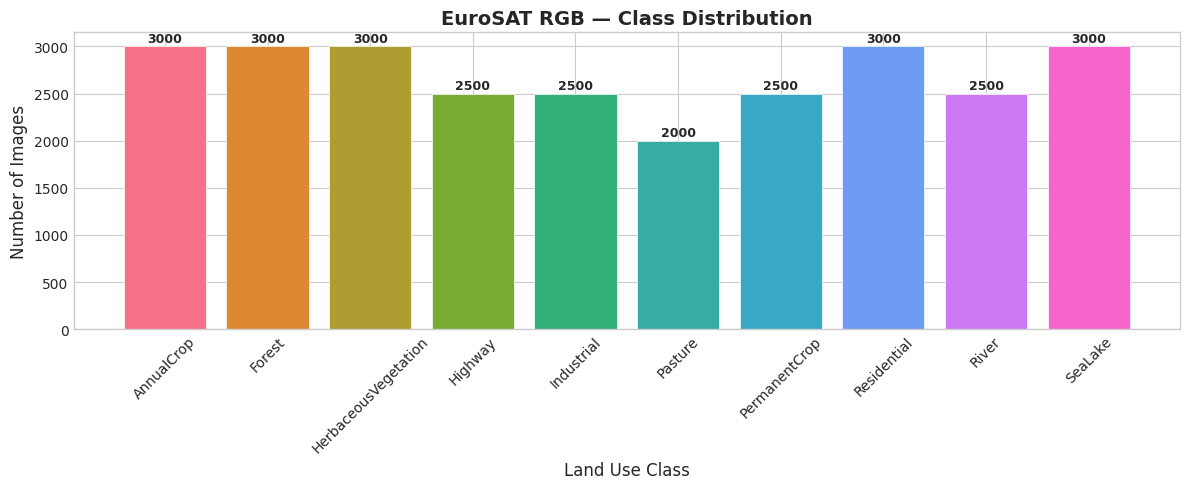

Class distribution plot saved


In [16]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))
counts = df_all["class_name"].value_counts().sort_index()
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Land Use Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("EuroSAT RGB — Class Distribution", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution plot saved")

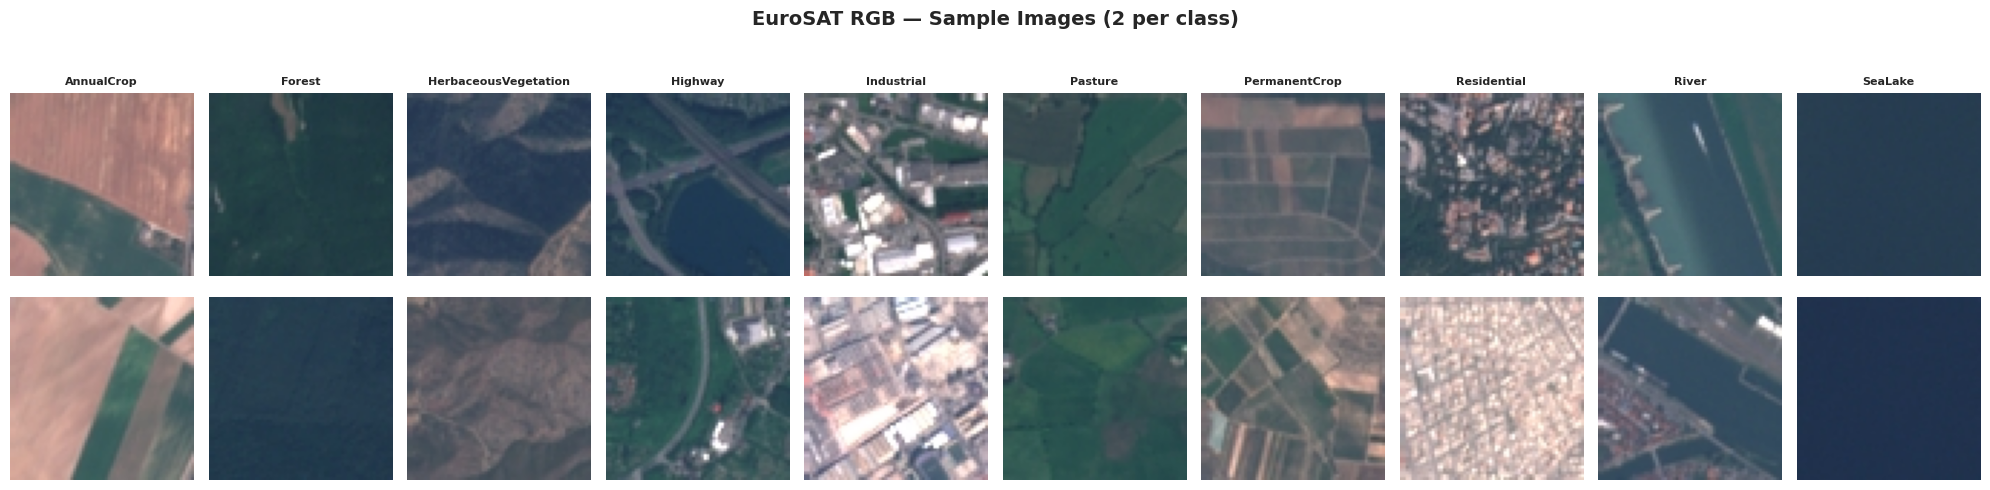

Sample images grid saved


In [17]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 5))
fig.suptitle("EuroSAT RGB — Sample Images (2 per class)", fontsize=14, fontweight="bold", y=1.02)

for col_idx, class_name in enumerate(CLASS_NAMES):
    class_df = df_all[df_all["class_name"] == class_name].sample(n=2, random_state=GLOBAL_SEED)
    for row_idx, (_, row) in enumerate(class_df.iterrows()):
        img = Image.open(row["filepath"]).convert("RGB")
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(class_name, fontsize=8, fontweight="bold")

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "sample_images_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample images grid saved")

In [19]:
from torchvision import transforms

print("Computing per-channel statistics...")

to_tensor = transforms.ToTensor()

sample_df = df_all.groupby("class_name", group_keys=False).apply(
    lambda x: x.sample(n=min(100, len(x)), random_state=GLOBAL_SEED)
).reset_index(drop=True)

pixel_sum = torch.zeros(3)
pixel_sq_sum = torch.zeros(3)
n_pixels = 0

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Stats"):
    img = Image.open(row["filepath"]).convert("RGB")
    tensor = to_tensor(img)
    pixel_sum += tensor.sum(dim=[1, 2])
    pixel_sq_sum += (tensor ** 2).sum(dim=[1, 2])
    n_pixels += tensor.shape[1] * tensor.shape[2]

dataset_mean = pixel_sum / n_pixels
dataset_std = torch.sqrt(pixel_sq_sum / n_pixels - dataset_mean ** 2)

print("\nEuroSAT RGB channel statistics:")
print(f"Mean: R={dataset_mean[0]:.4f}, G={dataset_mean[1]:.4f}, B={dataset_mean[2]:.4f}")
print(f"Std : R={dataset_std[0]:.4f}, G={dataset_std[1]:.4f}, B={dataset_std[2]:.4f}")

print("\nImageNet normalization (used for pretrained models)")
print("Mean: [0.485, 0.456, 0.406]")
print("Std : [0.229, 0.224, 0.225]")

channel_stats = {
    "eurosat_mean": dataset_mean.tolist(),
    "eurosat_std": dataset_std.tolist(),
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
    "n_images_sampled": len(sample_df),
}

with open(PROJECT_ROOT / "data" / "eda" / "channel_statistics.json", "w") as f:
    json.dump(channel_stats, f, indent=2)

print("Channel statistics saved")

Computing per-channel statistics...


Stats: 100%|██████████| 1000/1000 [00:02<00:00, 361.33it/s]


EuroSAT RGB channel statistics:
Mean: R=0.3477, G=0.3836, B=0.4108
Std : R=0.2019, G=0.1366, B=0.1170

ImageNet normalization (used for pretrained models)
Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]
Channel statistics saved


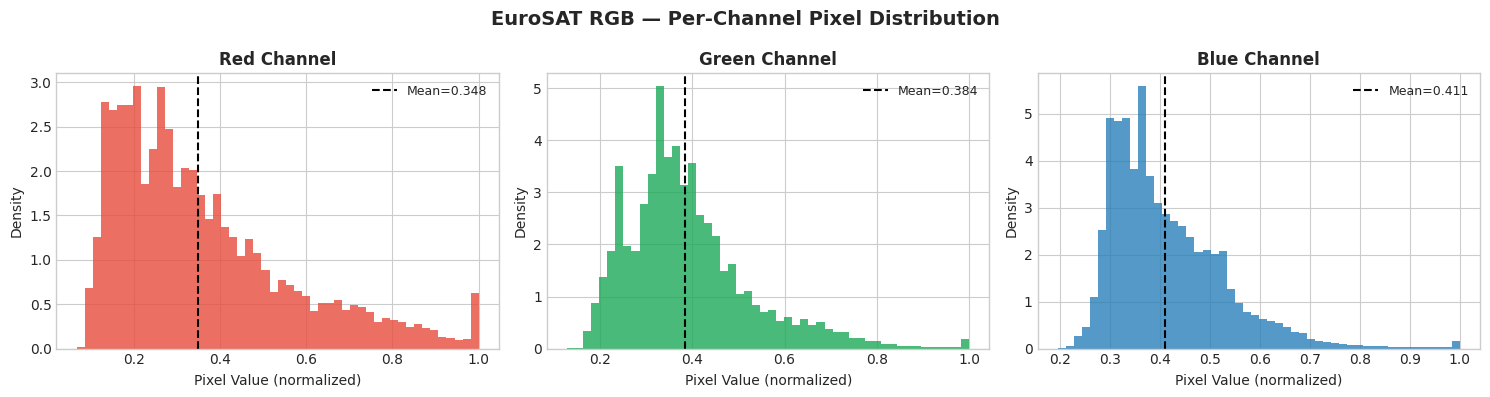

Channel histograms saved


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ["Red", "Green", "Blue"]
channel_colors = ["#e74c3c", "#1ca957", "#2980b9"]

all_pixels = {c: [] for c in range(3)}
for _, row in sample_df.sample(200, random_state=GLOBAL_SEED).iterrows():
    img = Image.open(row["filepath"]).convert("RGB")
    tensor = to_tensor(img)
    for c in range(3):
        all_pixels[c].extend(tensor[c].flatten().numpy())

for c in range(3):
    axes[c].hist(all_pixels[c], bins=50, color=channel_colors[c], alpha=0.8, density=True)
    axes[c].set_title(f"{channel_names[c]} Channel", fontsize=12, fontweight="bold")
    axes[c].set_xlabel("Pixel Value (normalized)")
    axes[c].set_ylabel("Density")
    axes[c].axvline(dataset_mean[c].item(), color="black", linestyle="--", linewidth=1.5,
                    label=f"Mean={dataset_mean[c]:.3f}")
    axes[c].legend(fontsize=9)

fig.suptitle("EuroSAT RGB — Per-Channel Pixel Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "channel_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Channel histograms saved")

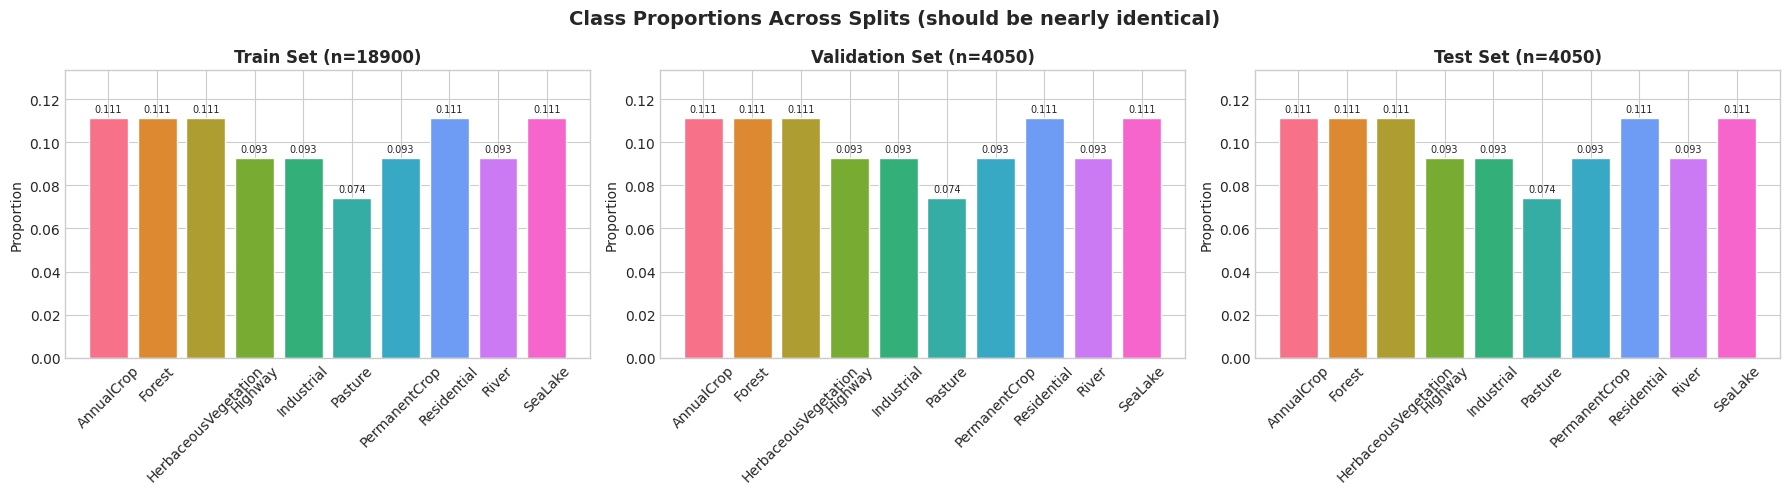

Max proportion drift between train and test: 0.0000
Stratification verified


In [21]:
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
split_names = ["Train", "Validation", "Test"]
split_dfs = [df_train, df_val, df_test]

for ax, name, df_split in zip(axes, split_names, split_dfs):
    counts_s = df_split["class_name"].value_counts().sort_index()
    proportions = counts_s / counts_s.sum()
    bars = ax.bar(proportions.index, proportions.values, color=colors, edgecolor="white")
    ax.set_title(f"{name} Set (n={len(df_split)})", fontsize=12, fontweight="bold")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, max(proportions.values) * 1.2)
    for bar, prop in zip(bars, proportions.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{prop:.3f}", ha="center", va="bottom", fontsize=7)

fig.suptitle("Class Proportions Across Splits (should be nearly identical)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "split_stratification_check.png", dpi=150, bbox_inches="tight")
plt.show()

train_props = df_train["class_name"].value_counts(normalize=True).sort_index()
test_props = df_test["class_name"].value_counts(normalize=True).sort_index()
max_drift = (train_props - test_props).abs().max()
print(f"Max proportion drift between train and test: {max_drift:.4f}")
assert max_drift < 0.02, "Stratification failed — drift too large"
print("Stratification verified")

In [26]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

print(model)
print("ResNet-18 loaded and classifier replaced for 10 classes")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/yash/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 15.3MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
train_loss, train_acc, train_f1 = train_one_epoch(
    model, train_loader, criterion, optimizer, device
)

val_loss, val_acc, val_f1 = evaluate(
    model, val_loader, criterion, device
)

print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")

print("One sanity epoch completed")


/home/yash/yc432/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Loss: 0.4573 | Train Acc: 0.8498 | Train F1: 0.8456
Val   Loss: 0.1869 | Val   Acc: 0.9390 | Val   F1: 0.9375
One sanity epoch completed


[✓] Loaded ImageNet pretrained weights
[✓] ResNet-18 ready on cpu
[✓] Final classifier: Linear(in_features=512, out_features=10, bias=True)


In [4]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Safe defaults if earlier cells were not run
if "config" in globals():
    num_classes = int(config.get("data", {}).get("num_classes", 10))
else:
    num_classes = 10

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Try pretrained; fallback to random init if download/network fails
try:
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    print("Loaded ImageNet pretrained weights")
except Exception as e:
    print(f"[!] Pretrained weights not available ({e}). Using weights=None.")
    model = resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(f"ResNet-18 ready on {device}")
print(f"Final classifier: {model.fc}")


Loaded ImageNet pretrained weights
ResNet-18 ready on cpu
Final classifier: Linear(in_features=512, out_features=10, bias=True)


In [ ]:
import torch.optim as optim
import torch.nn as nn

EPOCHS = 10
criterion = nn.CrossEntropyLoss()

lr = config["training"]["resnet18"]["lr"] if "config" in globals() else 1e-4
wd = config["training"]["resnet18"]["weight_decay"] if "config" in globals() else 1e-2

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Training setup ready for {EPOCHS} epochs")


[✓] Training setup ready for 10 epochs


In [8]:
from sklearn.metrics import accuracy_score, f1_score
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)


In [11]:
import json
import pathlib
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ---- Paths ----
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = pathlib.Path("/home/yash/yc432")  # change only if your repo is elsewhere

splits_dir = PROJECT_ROOT / "data" / "splits"

train_csv = splits_dir / "train.csv"
val_csv = splits_dir / "val.csv"
if not val_csv.exists():
    val_csv = splits_dir / "validation.csv"  # fallback if file is named validation.csv

if not train_csv.exists() or not val_csv.exists():
    raise FileNotFoundError(f"Missing split files in {splits_dir}. Found: {list(splits_dir.glob('*.csv'))}")

df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

# label column
label_col = "class_idx" if "class_idx" in df_train.columns else "label"
if label_col not in df_train.columns:
    raise ValueError(f"No label column found. Columns: {df_train.columns.tolist()}")

# ---- Transforms ----
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

class EuroSATDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        y = int(row[label_col])

        if self.transform is not None:
            img = self.transform(img)
        return img, y

train_dataset = EuroSATDataset(df_train, transform=train_transform)
val_dataset = EuroSATDataset(df_val, transform=eval_transform)

batch_size = 64
num_workers = 2
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory
)

print(f"[✓] train_loader ready: {len(train_loader)} batches")
print(f"[✓] val_loader ready:   {len(val_loader)} batches")


[✓] train_loader ready: 296 batches
[✓] val_loader ready:   64 batches


In [12]:
# Cell A — Model + optimizer setup (10 epochs)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

num_classes = 10 if "config" not in globals() else int(config["data"]["num_classes"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    model = resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("[✓] Model + optimizer ready")


[✓] Model + optimizer ready


In [13]:
# Cell B — Train / eval functions
from sklearn.metrics import accuracy_score, f1_score
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
    )

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
    )

print("[✓] train_one_epoch and evaluate ready")


[✓] train_one_epoch and evaluate ready


In [2]:
# Recovery setup cell: creates everything missing in one go
import json
from pathlib import Path
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score, f1_score

# ---- core config ----
PROJECT_ROOT = Path("/home/yash/yc432")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10
BATCH_SIZE = 64
NUM_WORKERS = 2
num_classes = 10

# ---- load splits ----
splits_dir = PROJECT_ROOT / "data" / "splits"
train_csv = splits_dir / "train.csv"
val_csv = splits_dir / "val.csv"
if not val_csv.exists():
    val_csv = splits_dir / "validation.csv"

if not train_csv.exists() or not val_csv.exists():
    raise FileNotFoundError(f"Missing split files. Found: {[p.name for p in splits_dir.glob('*.csv')]}")

df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)
label_col = "class_idx" if "class_idx" in df_train.columns else "label"

# ---- dataset/dataloaders ----
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class EuroSATDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = Image.open(row["filepath"]).convert("RGB")
        y = int(row[label_col])
        return self.transform(x), y

train_dataset = EuroSATDataset(df_train, train_transform)
val_dataset = EuroSATDataset(df_val, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

# ---- model/optim ----
try:
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    model = resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ---- train/eval funcs ----
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
    )

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
    )

print("[✓] Recovery setup done")
print(f"[✓] Device: {device}")
print(f"[✓] train batches: {len(train_loader)}, val batches: {len(val_loader)}")


[✓] Recovery setup done
[✓] Device: cpu
[✓] train batches: 296, val batches: 64


In [ ]:
from pathlib import Path
import torch

# assumes recovery/setup cell already ran
history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

best_val_acc = 0.0
best_model_path = PROJECT_ROOT / "checkpoints" / "resnet18_best_10ep.pth"
best_model_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_f1 = evaluate(
        model, val_loader, criterion, device
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"[✓] Saved best model -> {best_model_path}")

print(f"Training complete. Best val acc: {best_val_acc:.4f}")


Epoch 01/10 | Train Loss 0.3967 Acc 0.8679 F1 0.8638 | Val Loss 0.1679 Acc 0.9444 F1 0.9421
[✓] Saved best model -> /home/yash/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 02/10 | Train Loss 0.1849 Acc 0.9365 F1 0.9345 | Val Loss 0.1337 Acc 0.9556 F1 0.9541
[✓] Saved best model -> /home/yash/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 03/10 | Train Loss 0.1460 Acc 0.9494 F1 0.9477 | Val Loss 0.1359 Acc 0.9578 F1 0.9570
[✓] Saved best model -> /home/yash/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 04/10 | Train Loss 0.1152 Acc 0.9612 F1 0.9599 | Val Loss 0.0938 Acc 0.9691 F1 0.9681
[✓] Saved best model -> /home/yash/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 05/10 | Train Loss 0.0975 Acc 0.9661 F1 0.9650 | Val Loss 0.0961 Acc 0.9649 F1 0.9639
Epoch 06/10 | Train Loss 0.0862 Acc 0.9696 F1 0.9684 | Val Loss 0.0873 Acc 0.9701 F1 0.9691
[✓] Saved best model -> /home/yash/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 07/10 | Train Loss 0.0663 Acc 0.9772 F1 0.9763 | Val Loss 0.08